# download the data

In [2]:
import urllib.request
import zipfile
import os
import shutil

In [7]:
# dataset: https://data.mendeley.com/datasets/r4yhfnzc5y/1
# prior research paper: https://www.sciencedirect.com/science/article/pii/S2666154323004507#da0010

url = "https://data.mendeley.com/public-api/zip/r4yhfnzc5y/download/1"
file_path = "/content/lentils.zip"
extract_path = "/content/lentils_data"

print("Downloading dataset...")
# Add a User-Agent header to bypass the 403 Forbidden block
req = urllib.request.Request(
    url,
    headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
)

with urllib.request.urlopen(req) as response, open(file_path, 'wb') as out_file:
    out_file.write(response.read())

print("Download complete!")

Download complete!


In [8]:
# extract the files from zip
print("Extracting files...")
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset successfully extracted to {extract_path}!")

# for some reason it's double zipped
unzipped_subfolder_path = os.path.join(extract_path, "Indian Lentils")
double_zip_path = os.path.join(unzipped_subfolder_path, "Indian_Lentils.zip")
with zipfile.ZipFile(double_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
shutil.rmtree(unzipped_subfolder_path)

Extracting files...
Dataset successfully extracted to /content/lentils_data!


In [9]:
# double foldered
root_images_path = os.path.join(extract_path, "Indian_Lentils", "Indian_Lentils")
os.listdir(root_images_path)

['Black_Beans',
 'chana1',
 'Kidney_Bean',
 'Brown_Chickpea',
 'Whole_GreenGram',
 'Red_chickpea',
 'Red_KidneyBean',
 'chana2',
 'Whole_BlackGram',
 'Soya_Bean',
 'Horse_Gram',
 'Husked_RedLentil',
 'Whole_TurkishGram',
 'Desi_chickpea',
 'White_Chickpea',
 'White_beans',
 'Black_EyedPea',
 'Red_Beans',
 'White_peabeans',
 'Husked_BlackGram']

# Creating NN (POC)

In [10]:
import os
import urllib.request
import zipfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split
from math import ceil

In [11]:
# --- STEP 1: Setup Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(using_device := f"Using device: {device}")

Using device: cuda


In [21]:
# note: we will be using EfficientNet_B0 as per
# https://www.sciencedirect.com/science/article/pii/S2666154323004507#cited-by
efficientnet_transforms = models.EfficientNet_B0_Weights.DEFAULT.transforms()
print(efficientnet_transforms)
# we will use the following later
crop_size = efficientnet_transforms.crop_size[0]
resize_size = efficientnet_transforms.resize_size[0]
efficientnet_mean = efficientnet_transforms.mean
efficientnet_std = efficientnet_transforms.std

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [22]:
# --- STEP 2: Split Data and Setup Data Loader ---

train_transform = transforms.Compose([
    # Crops a random 80%-100% region and resizes to the crop size
    transforms.RandomResizedCrop(crop_size, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    # Normalize to standard ImageNet mean, SD
    transforms.Normalize(mean=efficientnet_mean, std=efficientnet_std)
])

eval_transform = transforms.Compose([
    transforms.Resize(resize_size), # give room to center crop
    transforms.CenterCrop(crop_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=efficientnet_mean, std=efficientnet_std)
])

full_train = datasets.ImageFolder(root=root_images_path, transform=train_transform)
full_eval = datasets.ImageFolder(root=root_images_path, transform=eval_transform)

targets = [label for _, label in full_train.samples]
train_idx, test_idx = train_test_split(
    range(len(full_train)), test_size=0.2, random_state=42, stratify=targets
)

train_dataset = Subset(full_train, train_idx)
eval_dataset = Subset(full_eval, test_idx)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)

In [23]:
print(f"Total classes found: {len(full_train.classes)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Eval dataset size: {len(eval_dataset)}")

Total classes found: 20
Train dataset size: 8000
Eval dataset size: 2000


In [32]:
# --- STEP 2: Setup Model (Transfer Learning) ---
# Using EfficientNetB0 for best performance
weights = models.EfficientNet_B0_Weights.DEFAULT

# Modify final layer to match our 20 lentil categories
def make_efficientnet_model():
  model = models.efficientnet_b0(weights=weights)
  model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(full_train.classes))
  return model.to(device)

model = make_efficientnet_model()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
# --- STEP 3: Quick Sanity Check Training Loop ---
print("\nStarting quick training test (1 epoch)...")
model.train()
running_loss = 0.0

for batch_idx, (images, labels) in enumerate(train_loader):
    images, labels = images.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    if batch_idx % 50 == 0:
        print(f"Batch {batch_idx}/{len(train_loader)} - Loss: {loss.item():.4f}")

print("\n MVP Success! Your pipeline is fully functional and training on the GPU.")


Starting quick training test (1 epoch)...
Batch 0/250 - Loss: 2.9864
Batch 50/250 - Loss: 0.0635
Batch 100/250 - Loss: 0.1494
Batch 150/250 - Loss: 0.2422
Batch 200/250 - Loss: 0.0494

 MVP Success! Your pipeline is fully functional and training on the GPU.


## Train with some experiments

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import classification_report, confusion_matrix
import time

In [36]:
def train_and_time(model, criterion, optimizer, num_epochs, use_amp):
  # whether to use mixed precision
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
  epoch_times = []
  eval_accs = []

  for epoch in range(num_epochs):
      model.train()
      torch.cuda.synchronize()
      start = time.perf_counter()

      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)

          optimizer.zero_grad()
          with torch.cuda.amp.autocast(enabled=use_amp):
              outputs = model(images)
              loss = criterion(outputs, labels)
          scaler.scale(loss).backward()
          scaler.step(optimizer)
          scaler.update()

      torch.cuda.synchronize()
      epoch_times.append(time.perf_counter() - start)

      model.eval()
      correct, total = 0, 0
      with torch.no_grad():
          for images, labels in eval_loader:
              images, labels = images.to(device), labels.to(device)
              with torch.cuda.amp.autocast(enabled=use_amp):
                  outputs = model(images)
              _, preds = torch.max(outputs, 1)
              correct += (preds == labels).sum().item()
              total += labels.size(0)
      eval_accs.append(correct / total)

      tag = "AMP" if use_amp else "FP32"
      print(f"[{tag}] Epoch {epoch+1}/{num_epochs} — Time: {epoch_times[-1]:.2f}s — Eval Acc: {eval_accs[-1]:.4f}")

  return epoch_times, eval_accs

Try using AMP vs Not Using AMP

AMP uses approximated values (less precision), which could be faster for computation.

In [37]:
num_epochs=7

# baseline model - fp32; no amp approximation
model_base = make_efficientnet_model()
base_times, base_accs = train_and_time(
    model=model_base,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(model_base.parameters(), lr=0.001),
    num_epochs=num_epochs,
    use_amp=False
)

# using AMP approximation
model_amp = make_efficientnet_model()
amp_times, amp_accs = train_and_time(
    model=model_amp,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(model_amp.parameters(), lr=0.001),
    num_epochs=num_epochs,
    use_amp=True
)

/tmp/ipykernel_1272/3782634375.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_1272/3782634375.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_1272/3782634375.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[FP32] Epoch 1/7 — Time: 39.48s — Eval Acc: 0.9895
[FP32] Epoch 2/7 — Time: 44.26s — Eval Acc: 0.9975
[FP32] Epoch 3/7 — Time: 39.84s — Eval Acc: 0.9980
[FP32] Epoch 4/7 — Time: 40.17s — Eval Acc: 0.9355
[FP32] Epoch 5/7 — Time: 39.99s — Eval Acc: 0.9980
[FP32] Epoch 6/7 — Time: 40.02s — Eval Acc: 0.9960
[FP32] Epoch 7/7 — Time: 40.18s — Eval Acc: 0.9990
[AMP] Epoch 1/7 — Time: 55.22s — Eval Acc: 0.9200
[AMP] Epoch 2/7 — Time: 44.89s — Eval Acc: 0.9965
[AMP] Epoch 3/7 — Time: 43.53s — Eval Acc: 0.9990
[AMP] Epoch 4/7 — Time: 43.50s — Eval Acc: 1.0000
[AMP] Epoch 5/7 — Time: 43.90s — Eval Acc: 0.9910
[AMP] Epoch 6/7 — Time: 44.77s — Eval Acc: 0.9990
[AMP] Epoch 7/7 — Time: 44.52s — Eval Acc: 0.9595


AMP did not provide a speedup for this architecture on a T4, likely because EfficientNet's depthwise convolutions are memory-bandwidth-bound rather than compute-bound, so Tensor Core acceleration had little to act on.

In [39]:
# print summary stats
avg_base = sum(base_times) / len(base_times)
avg_amp = sum(amp_times) / len(amp_times)
print(f"\nAvg FP32 epoch time: {avg_base:.2f}s")
print(f"Avg AMP  epoch time: {avg_amp:.2f}s")
print(f"Speedup: {avg_base/avg_amp:.2f}x")
print(f"Final FP32 eval acc: {base_accs[-1]:.4f}  |  Final AMP eval acc: {amp_accs[-1]:.4f}")


Avg FP32 epoch time: 40.56s
Avg AMP  epoch time: 45.76s
Speedup: 0.89x
Final FP32 eval acc: 0.9990  |  Final AMP eval acc: 0.9595


Let's try torch.compile

Theoretically since EfficientNEt suffers from overhead with a memory-bandwidth-bound, many-small-ops architecture, torch.compile can help.

torch.compile fuses consecutive small operations (conv→batchnorm→activation, for instance) into fewer, larger GPU kernels. That directly reduces the number of times intermediate results get written to and read back from GPU memory between ops.

In [40]:
# train compiled model
model_compiled = torch.compile(make_efficientnet_model())

compiled_times, compiled_accs = train_and_time(
    model=model_compiled,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(model_compiled.parameters(), lr=0.001),
    num_epochs=7,
    use_amp=False,   # keep precision constant — isolate torch.compile as the only new variable
)

/tmp/ipykernel_1272/3782634375.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_1272/3782634375.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
W0926 05:53:35.656000 1272 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/tmp/ipykernel_1272/3782634375.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_1272/3782634375.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_1272/3782634375.py:31: Futur

[FP32] Epoch 1/7 — Time: 192.85s — Eval Acc: 0.9965


/tmp/ipykernel_1272/3782634375.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_1272/3782634375.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[FP32] Epoch 2/7 — Time: 55.00s — Eval Acc: 0.9975
[FP32] Epoch 3/7 — Time: 56.09s — Eval Acc: 0.9960
[FP32] Epoch 4/7 — Time: 56.16s — Eval Acc: 0.9970
[FP32] Epoch 5/7 — Time: 56.30s — Eval Acc: 1.0000
[FP32] Epoch 6/7 — Time: 56.15s — Eval Acc: 0.9955
[FP32] Epoch 7/7 — Time: 57.95s — Eval Acc: 0.9995


In [41]:
avg_compiled = sum(compiled_times[1:]) / len(compiled_times[1:])  # exclude epoch 1 bc typically disproportionately slower.
print(f"Avg FP32 eager epoch time:     {avg_base:.2f}s")
print(f"Avg torch.compile epoch time:  {avg_compiled:.2f}s")
print(f"Speedup: {avg_base/avg_compiled:.2f}x")

Avg FP32 eager epoch time:     40.56s
Avg torch.compile epoch time:  56.28s
Speedup: 0.72x


Torch.compile wasn't successful either.

 cuDNN (what eager PyTorch uses under the hood) has extremely mature, hand-tuned kernels for standard conv/batchnorm operations — the product of years of NVIDIA engineering effort specifically targeting these ops. torch.compile's Inductor backend instead generates its own GPU kernels via Triton and normally relies on its aggressive "max-autotune" search to find kernels competitive with cuDNN's hand-tuned ones. You just saw that exact search get disabled on your T4 because of its limited SM count. Without that search, Inductor falls back to more generic kernel-generation, which on this GPU apparently isn't beating cuDNN's already-excellent baseline — so the fusion benefit you'd normally hope for gets outweighed by using worse-tuned kernels underneath. This is a documented, known failure mode: torch.compile isn't a universal win, and its benefit is genuinely GPU-dependent (it tends to shine most on newer/bigger GPUs where max-autotune is available).

It's worth exploring whether a different architecture might be more successful on the T4 GPU which we are limited to.

Hypothesis:
EfficientNetB0 was explicitly designed to minimize FLOPs (~0.39 GFLOPs vs. ResNet18's ~1.8 GFLOPs at similar resolution) — on paper, EfficientNet does roughly 4-5x less "work." But raw FLOP count doesn't predict GPU latency.

EfficientNet includes small sequential operations. ResNet FLOPs are more but are better organized in a GPU-friendly, high-arithmetic-intensity, well-optimized pattern, while EfficientNet's FLOP-efficiency comes at the cost of GPU-unfriendly operation structure.

In [42]:
def make_resnet_model():
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    m.fc = nn.Linear(m.fc.in_features, len(full_train.classes))
    return m.to(device)

In [43]:
model_resnet_base = make_resnet_model()
resnet_base_times, resnet_base_accs = train_and_time(
    model=model_resnet_base,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(model_resnet_base.parameters(), lr=0.001),
    num_epochs=7,
    use_amp=False,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]
/tmp/ipykernel_1272/3782634375.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_1272/3782634375.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_1272/3782634375.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[FP32] Epoch 1/7 — Time: 34.31s — Eval Acc: 0.7585
[FP32] Epoch 2/7 — Time: 28.00s — Eval Acc: 0.9725
[FP32] Epoch 3/7 — Time: 34.88s — Eval Acc: 0.9685
[FP32] Epoch 4/7 — Time: 27.63s — Eval Acc: 0.8625
[FP32] Epoch 5/7 — Time: 29.14s — Eval Acc: 0.9890
[FP32] Epoch 6/7 — Time: 28.57s — Eval Acc: 0.9785
[FP32] Epoch 7/7 — Time: 26.35s — Eval Acc: 0.9455


In [45]:
# print summary stats
avg_resnet_base = sum(resnet_base_times) / len(resnet_base_times)
print(f"\nAvg EfficientNet epoch time: {avg_base:.2f}s")
print(f"Avg Resnet epoch time: {avg_resnet_base:.2f}s")
print(f"Speedup: {avg_base/avg_resnet_base:.2f}x")
print(f"Final Resnet eval acc: {resnet_base_accs[-1]:.4f}  |  Final EfficientNet eval acc: {base_accs[-1]:.4f}")


Avg EfficientNet epoch time: 40.56s
Avg Resnet epoch time: 29.84s
Speedup: 1.36x
Final Resnet eval acc: 0.9455  |  Final EfficientNet eval acc: 0.9990


The eval accuracy is swinging so let's try a lower learning rate

In [46]:
model_resnet_base = make_resnet_model()
resnet_base_times, resnet_base_accs = train_and_time(
    model=model_resnet_base,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(model_resnet_base.parameters(), lr=0.0001),
    num_epochs=7,
    use_amp=False,
)
# print summary stats
avg_resnet_base = sum(resnet_base_times) / len(resnet_base_times)
print(f"\nAvg EfficientNet epoch time: {avg_base:.2f}s")
print(f"Avg Resnet epoch time: {avg_resnet_base:.2f}s")
print(f"Speedup: {avg_base/avg_resnet_base:.2f}x")
print(f"Final Resnet eval acc: {resnet_base_accs[-1]:.4f}  |  Final EfficientNet eval acc: {base_accs[-1]:.4f}")

/tmp/ipykernel_1272/3782634375.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_1272/3782634375.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_1272/3782634375.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[FP32] Epoch 1/7 — Time: 27.89s — Eval Acc: 0.9995
[FP32] Epoch 2/7 — Time: 25.42s — Eval Acc: 0.9995
[FP32] Epoch 3/7 — Time: 25.34s — Eval Acc: 0.9990
[FP32] Epoch 4/7 — Time: 25.83s — Eval Acc: 0.9750
[FP32] Epoch 5/7 — Time: 26.45s — Eval Acc: 0.9935
[FP32] Epoch 6/7 — Time: 26.30s — Eval Acc: 0.9995
[FP32] Epoch 7/7 — Time: 26.24s — Eval Acc: 0.9990

Avg EfficientNet epoch time: 40.56s
Avg Resnet epoch time: 26.21s
Speedup: 1.55x
Final Resnet eval acc: 0.9990  |  Final EfficientNet eval acc: 0.9990


What happens if I use AMP?

In [47]:
model_resnet_base = make_resnet_model()
resnet_base_times, resnet_base_accs = train_and_time(
    model=model_resnet_base,
    criterion=nn.CrossEntropyLoss(),
    optimizer=optim.Adam(model_resnet_base.parameters(), lr=0.0001),
    num_epochs=7,
    use_amp=True,
)
# print summary stats
avg_resnet_base = sum(resnet_base_times) / len(resnet_base_times)
print(f"\nAvg EfficientNet epoch time: {avg_base:.2f}s")
print(f"Avg Resnet epoch time: {avg_resnet_base:.2f}s")
print(f"Speedup: {avg_base/avg_resnet_base:.2f}x")
print(f"Final Resnet eval acc: {resnet_base_accs[-1]:.4f}  |  Final EfficientNet eval acc: {base_accs[-1]:.4f}")

/tmp/ipykernel_1272/3782634375.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
/tmp/ipykernel_1272/3782634375.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_1272/3782634375.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


[AMP] Epoch 1/7 — Time: 32.97s — Eval Acc: 0.9920
[AMP] Epoch 2/7 — Time: 31.88s — Eval Acc: 0.9975
[AMP] Epoch 3/7 — Time: 28.98s — Eval Acc: 0.9995
[AMP] Epoch 4/7 — Time: 32.89s — Eval Acc: 0.9785
[AMP] Epoch 5/7 — Time: 34.37s — Eval Acc: 0.9985
[AMP] Epoch 6/7 — Time: 29.80s — Eval Acc: 0.9995
[AMP] Epoch 7/7 — Time: 32.64s — Eval Acc: 0.9990

Avg EfficientNet epoch time: 40.56s
Avg Resnet epoch time: 31.93s
Speedup: 1.27x
Final Resnet eval acc: 0.9990  |  Final EfficientNet eval acc: 0.9990


### old

In [27]:
train_losses, train_accuracies = [], []
eval_losses, eval_accuracies = [], []

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(running_loss / len(train_dataset))
    train_accuracies.append(correct / total)

    model.eval()
    running_eval_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in eval_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_eval_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    eval_losses.append(running_eval_loss / len(eval_dataset))
    eval_accuracies.append(correct / total)

    print(f"Epoch {epoch+1}/{num_epochs} — "
          f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f} — "
          f"Eval Loss: {eval_losses[-1]:.4f}, Eval Acc: {eval_accuracies[-1]:.4f}")

# epoch times

# default:
# 1: 2 min
# 2: 2:25
# 3:
# ~11:30 min for 10 epochs = ~69 sec / epoch



Epoch 1/10 — Train Loss: 0.0798, Train Acc: 0.9791 — Eval Loss: 0.2249, Eval Acc: 0.9505
Epoch 2/10 — Train Loss: 0.0291, Train Acc: 0.9931 — Eval Loss: 0.0106, Eval Acc: 0.9970
Epoch 3/10 — Train Loss: 0.0374, Train Acc: 0.9900 — Eval Loss: 0.0466, Eval Acc: 0.9860
Epoch 4/10 — Train Loss: 0.0277, Train Acc: 0.9915 — Eval Loss: 0.1696, Eval Acc: 0.9665
Epoch 5/10 — Train Loss: 0.0164, Train Acc: 0.9955 — Eval Loss: 0.0079, Eval Acc: 0.9985
Epoch 6/10 — Train Loss: 0.0179, Train Acc: 0.9949 — Eval Loss: 0.0052, Eval Acc: 0.9995
Epoch 7/10 — Train Loss: 0.0095, Train Acc: 0.9975 — Eval Loss: 0.0001, Eval Acc: 1.0000
Epoch 8/10 — Train Loss: 0.0147, Train Acc: 0.9970 — Eval Loss: 0.0060, Eval Acc: 0.9980
Epoch 9/10 — Train Loss: 0.0307, Train Acc: 0.9916 — Eval Loss: 0.0097, Eval Acc: 0.9975
Epoch 10/10 — Train Loss: 0.0206, Train Acc: 0.9941 — Eval Loss: 0.0052, Eval Acc: 0.9980


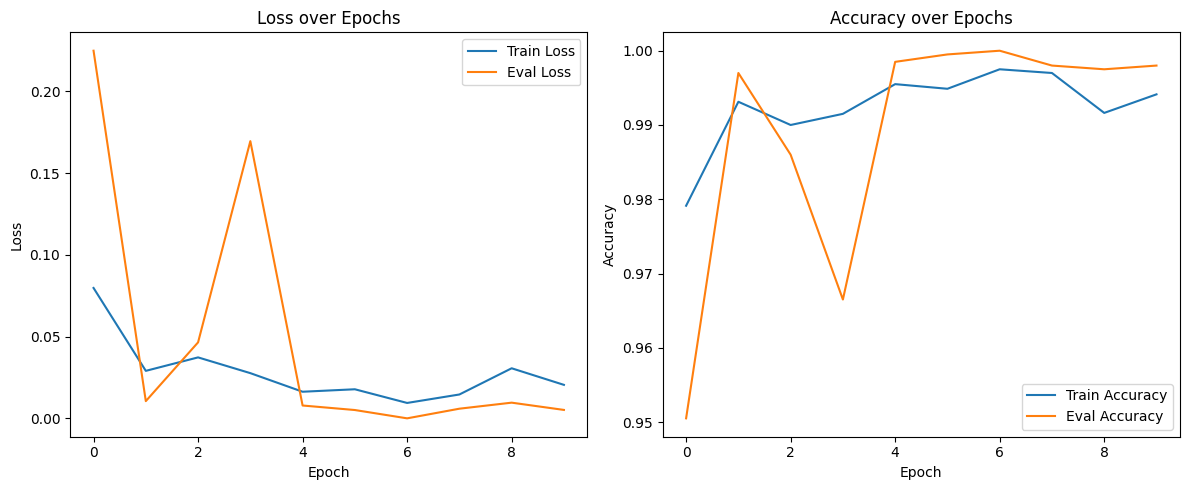

In [28]:
# plot training and eval accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(eval_losses, label="Eval Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[0].set_title("Loss over Epochs")

axes[1].plot(train_accuracies, label="Train Accuracy")
axes[1].plot(eval_accuracies, label="Eval Accuracy")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
axes[1].set_title("Accuracy over Epochs")

plt.tight_layout()
plt.show()


In [29]:
# Run evaluation on the eval set to collect predictions and truths
model.eval()
all_preds = []
all_labels = []

sample_images = []
sample_preds = []
sample_truth = []

with torch.no_grad():
    for images, labels in eval_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        if len(sample_images) < 8:
            for i in range(min(8 - len(sample_images), images.size(0))):
                sample_images.append(images[i].cpu())
                sample_preds.append(preds[i].item())
                sample_truth.append(labels[i].item())

### Results

In [30]:
# 2. Print Per-Class Metrics and Accuracy
class_names = full_train.classes
print("--- CLASSIFICATION REPORT ---")
print(
    classification_report(
        all_labels, all_preds, target_names=class_names, zero_division=0
    )
)

--- CLASSIFICATION REPORT ---
                   precision    recall  f1-score   support

      Black_Beans       1.00      0.99      0.99       100
    Black_EyedPea       1.00      1.00      1.00       100
   Brown_Chickpea       1.00      1.00      1.00       100
    Desi_chickpea       1.00      1.00      1.00       100
       Horse_Gram       1.00      1.00      1.00       100
 Husked_BlackGram       1.00      0.99      0.99       100
 Husked_RedLentil       1.00      1.00      1.00       100
      Kidney_Bean       1.00      0.99      0.99       100
        Red_Beans       1.00      0.99      0.99       100
   Red_KidneyBean       0.99      1.00      1.00       100
     Red_chickpea       1.00      1.00      1.00       100
        Soya_Bean       1.00      1.00      1.00       100
   White_Chickpea       1.00      1.00      1.00       100
      White_beans       1.00      1.00      1.00       100
   White_peabeans       0.98      1.00      0.99       100
  Whole_BlackGram       0


--- PLOTTING 20-CLASS REPRESENTATIVE GRID ---


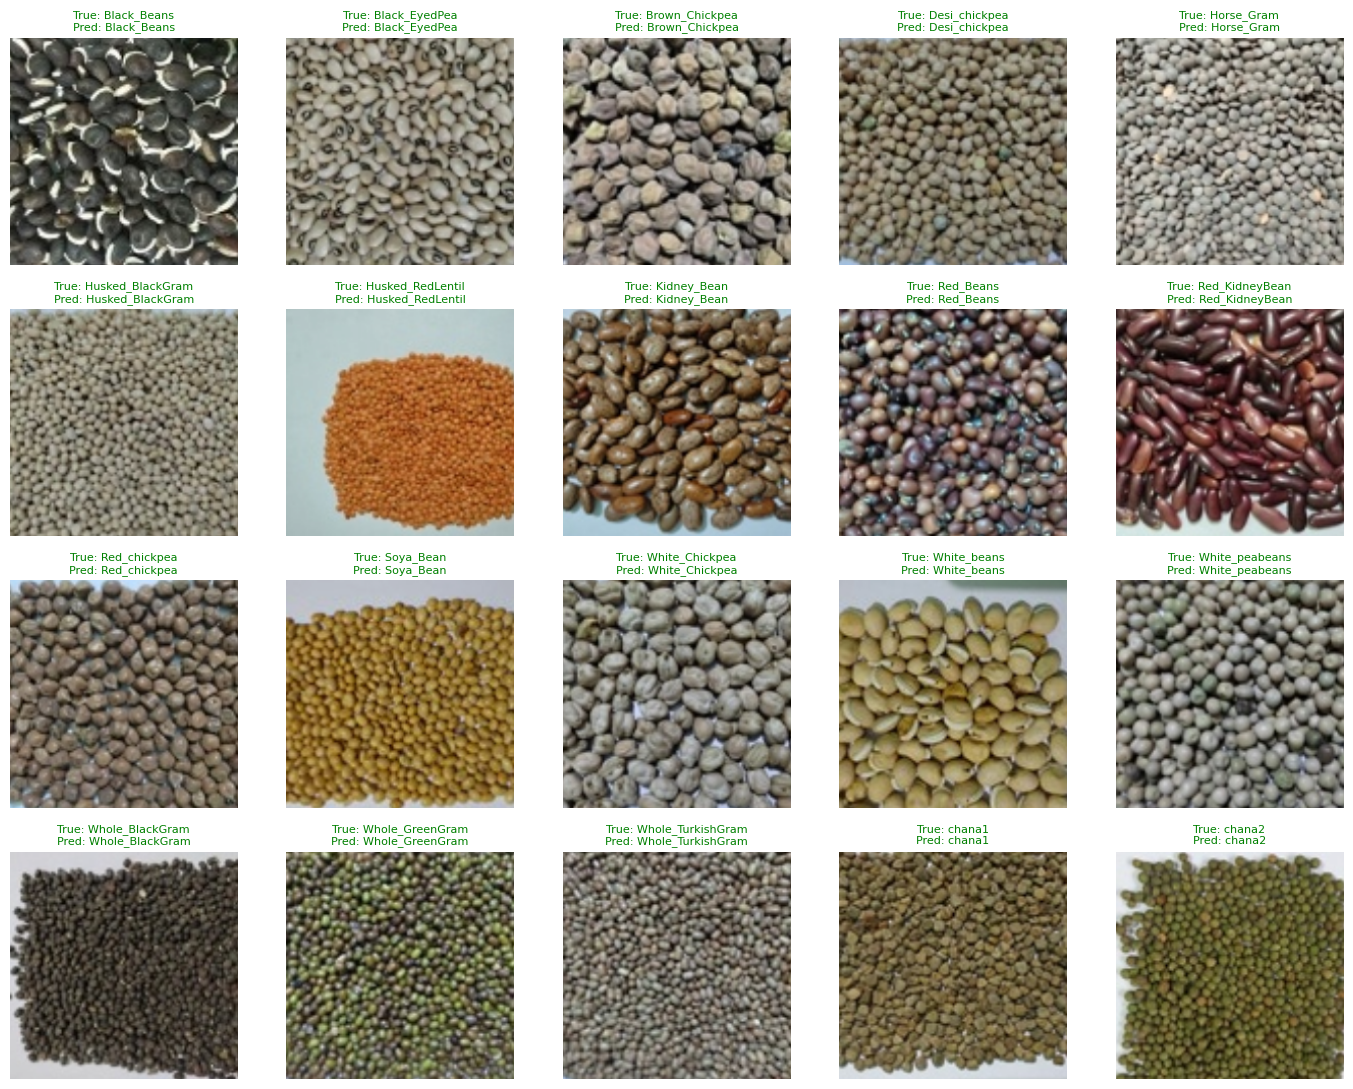

In [31]:
# 2. Collect exactly ONE sample per class for the 20-class grid
class_samples = {}
model.eval()
with torch.no_grad():
  for images, labels in eval_loader:
    for img, label in zip(images, labels):
      label_idx = label.item()
      if label_idx not in class_samples:
        outputs = model(img.unsqueeze(0).to(device))
        _, pred = torch.max(outputs, 1)
        class_samples[label_idx] = {
            "image": img.cpu(),
            "pred": pred.item(),
            "truth": label_idx,
        }
      if len(class_samples) == len(class_names):
        break
    if len(class_samples) == len(class_names):
      break

# 3. Plot a 4x5 grid (4 rows, 5 columns = 20 images total)
print("\n--- PLOTTING 20-CLASS REPRESENTATIVE GRID ---")
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
axes = axes.flatten()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

for i in range(len(class_names)):
  sample = class_samples[i]
  img = sample["image"].numpy().transpose((1, 2, 0))
  img = std * img + mean
  img = np.clip(img, 0, 1)

  true_label = class_names[sample["truth"]]
  pred_label = class_names[sample["pred"]]

  axes[i].imshow(img)
  axes[i].axis("off")

  color = "green" if true_label == pred_label else "red"
  axes[i].set_title(
      f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=8
  )

plt.tight_layout()
plt.show()